In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
df = pd.read_csv("/Users/semanurcan/Desktop/veri/birlesik_veri.csv")
df.head()

,hour,passenger_count,vehicle_type,route_code,stop_code,district,is_outlier,is_peak_hour,mean_passenger_by_route_hour
0,0,2,2,KIRAZLI-BASAKSEHIR/METROKENT,RAYLI,BAGCILAR,0,0,1.532982
1,0,2,2,YENIKAPI - HAVALIMANI,RAYLI,BAHCELIEVLER,0,0,2.980226
2,0,1,2,BAHARIYE-OLIMPIYAT,RAYLI,BAKIRKOY,0,0,1.473945
3,0,9,2,KABATAS-BAGCILAR,RAYLI,BAKIRKOY,1,0,3.376855
4,0,2,2,YENIKAPI - HACIOSMAN,RAYLI,BEYOGLU,0,0,2.826446


Veri seti CSV dosyasından okunarak DataFrame’e aktarılmış ve ilk 5 satır kontrol edilmiştir.

In [3]:
target_col = "is_peak_hour"

feature_cols = [
    "passenger_count",
    "vehicle_type",
    "district",
    "route_code",
    "stop_code",
    "is_outlier"
]

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((3679416, 6), (919854, 6))

- Tahmin edilecek hedef değişken ve kullanılacak özellikler belirlenmiş, 
- ardından veri **%80 eğitim** ve **%20 test** olacak şekilde dengeli biçimde ayrılmıştır.

In [4]:
numeric_features = ["passenger_count"]
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_np = preprocess.fit_transform(X_train)
X_test_np  = preprocess.transform(X_test)

if hasattr(X_train_np, "toarray"):
    X_train_np = X_train_np.toarray()
    X_test_np  = X_test_np.toarray()

y_train_np = y_train.values
y_test_np  = y_test.values

X_train_np.shape

(3679416, 974)

- Sayısal ve kategorik değişkenler için ayrı ön-işleme adımları uygulanmış,
- eksik değerler uygun yöntemlerle doldurulmuş ve kategorik değişkenler **One-Hot Encoding** ile 
sayısal forma dönüştürülerek model eğitimine hazır hale getirilmiştir.

In [5]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularDataset(X_train_np, y_train_np)
test_ds  = TabularDataset(X_test_np, y_test_np)

train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=4096, shuffle=False)

- Önişlenmiş veriler PyTorch ile kullanılabilmesi için Dataset yapısına dönüştürülmüş, 
- eğitim ve test aşamalarında kullanılmak üzere **DataLoader** nesneleri oluşturulmuştur.

In [6]:
input_dim = X_train_np.shape[1]
num_classes = len(np.unique(y_train_np))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MLP(input_dim, num_classes).to(device)

device

device(type='mps')

- Girdi özellik sayısına göre çok katmanlı bir yapay sinir ağı (MLP) tanımlanmış,
- ReLU aktivasyon ve Dropout kullanılarak modelin öğrenme kapasitesi artırılmış ve aşırı öğrenme (overfitting) azaltılmıştır.
- Model, mevcut donanıma göre CPU veya Apple MPS üzerinde çalışacak şekilde yapılandırılmıştır.

In [7]:
class_counts = np.bincount(y_train_np)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

- Sınıflar arasındaki dengesizliği azaltmak amacıyla eğitim verisindeki sınıf frekanslarına göre ağırlıklar hesaplanmış,
bu ağırlıklar **CrossEntropyLoss** fonksiyonuna eklenerek modelin az görülen sınıflara daha fazla önem vermesi sağlanmıştır.
- Optimizasyon işlemi için **Adam algoritması** kullanılmıştır.


In [8]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            pred = torch.argmax(out, dim=1)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    return (
        accuracy_score(trues, preds),
        f1_score(trues, preds, average="macro"),
        trues,
        preds
    )

best_f1 = 0
patience = 3
wait = 0

for epoch in range(1, 21):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    acc, f1, _, _ = evaluate(model, test_loader)
    print(f"Epoch {epoch:02d} | loss {total_loss:.3f} | acc {acc:.4f} | f1 {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_state)

Epoch 01 | loss 1220.888 | acc 0.5703 | f1 0.5703
Epoch 02 | loss 1216.864 | acc 0.5715 | f1 0.5715
Epoch 03 | loss 1215.518 | acc 0.5716 | f1 0.5716
Epoch 04 | loss 1214.691 | acc 0.5725 | f1 0.5724
Epoch 05 | loss 1214.134 | acc 0.5727 | f1 0.5727
Epoch 06 | loss 1213.596 | acc 0.5729 | f1 0.5729
Epoch 07 | loss 1213.172 | acc 0.5734 | f1 0.5733
Epoch 08 | loss 1212.739 | acc 0.5735 | f1 0.5731
Epoch 09 | loss 1212.395 | acc 0.5736 | f1 0.5731
Epoch 10 | loss 1212.161 | acc 0.5734 | f1 0.5730
Early stopping


<All keys matched successfully>

- **evaluate()** fonksiyonu modelin test verisi üzerindeki accuracy ve macro F1 skorlarını hesaplamak için tanımlanmıştır.
- Eğitim sürecinde model her epoch sonunda test verisi ile değerlendirilmiştir.
- CrossEntropyLoss ve **Adam algoritması** kullanılarak ağ ağırlıkları güncellenmiştir.
- Early stopping mekanizması ile F1 skoru artmadığında eğitim erken durdurulmuştur.
- En iyi F1 skorunu veren model ağırlıkları tekrar yüklenmiştir.

In [9]:
acc, f1, y_true, y_pred = evaluate(model, test_loader)

print("Accuracy:", acc)
print("F1 macro:", f1)
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.57336925207696
F1 macro: 0.5730225941514817
              precision    recall  f1-score   support

           0       0.57      0.60      0.59    464228
           1       0.57      0.55      0.56    455626

    accuracy                           0.57    919854
   macro avg       0.57      0.57      0.57    919854
weighted avg       0.57      0.57      0.57    919854

[[276813 187415]
 [205023 250603]]


- Eğitilen model, test veri kümesi üzerinde değerlendirilmiştir.
- *Accuracy* ve *macro F1-score* metrikleri hesaplanmıştır.
- Sınıf bazlı performansı görmek için classification report oluşturulmuştur.
- Gerçek ve tahmin edilen sınıflar arasındaki ilişki *confusion matrix* ile gösterilmiştir.

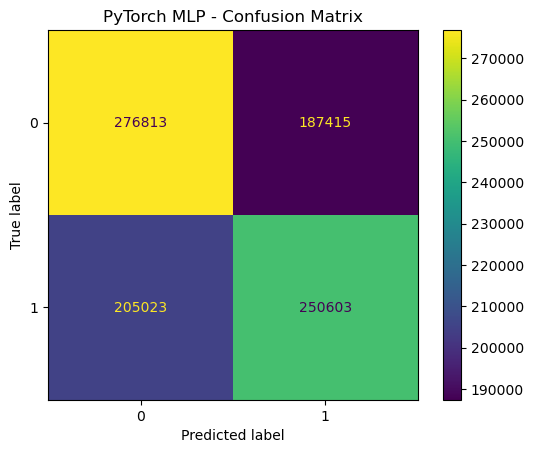

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=["0", "1"],
    values_format="d"
)

plt.title("PyTorch MLP - Confusion Matrix")
plt.show()

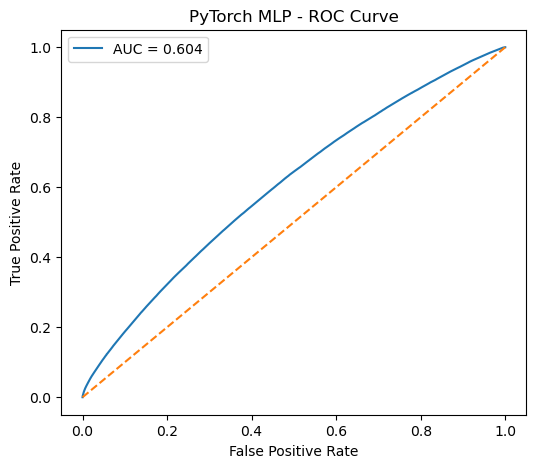

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model.eval()
probs = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        p = torch.softmax(out, dim=1)[:, 1] 
        probs.append(p.cpu().numpy())

y_score = np.concatenate(probs)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PyTorch MLP - ROC Curve")
plt.legend()
plt.show()

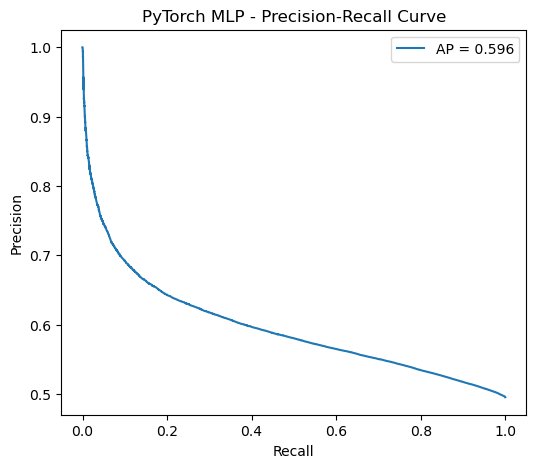

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PyTorch MLP - Precision-Recall Curve")
plt.legend()
plt.show()